In [ ]:
import os
import random
import numpy as np
import pandas as pd
import glob
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from google.colab import drive

# Seeds para reprodutibilidade
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

drive.mount('/content/drive')

# --- CONFIGURAÇÃO DE CAMINHOS ---
dataset_path = '/content/drive/MyDrive/TCC/PKG - Osteosarcoma Tumor Assessment'
csv_path = '/content/drive/MyDrive/TCC/ML_Features_1144.csv'
save_model_path = '/content/drive/MyDrive/TCC/Modelos_Osteosarcoma'

os.makedirs(save_model_path, exist_ok=True)

# NOMES PARA O TESTE DE 3 CLASSES
checkpoint_path = os.path.join(save_model_path, 'melhor_modelo_3classes_CLAHE_temp.keras')
final_model_name = os.path.join(save_model_path, 'EfficientNetB1_Osteosarcoma_3classes_CLAHE_Final.keras')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100

Mounted at /content/drive


In [ ]:
def apply_clahe_yuv(image):
    """
    Converte RGB -> YUV, aplica CLAHE no canal Y, e retorna para RGB.
    """
    img_uint8 = image.astype('uint8')

    # 1. Converter de RGB para YUV
    yuv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2YUV)

    # 2. Aplicar CLAHE no canal de Luminância (Y)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    yuv[:,:,0] = clahe.apply(yuv[:,:,0])

    # 3. Converter de volta para RGB
    img_final = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    return img_final.astype('float32')

In [ ]:
print("Iniciando carregamento e mapeamento...")
df_original = pd.read_csv(csv_path)

# Criando uma cópia segura para trabalhar
df_copia = df_original.copy()

# ==============================================================================
# ALTERAÇÃO DO DATASET: Agrupando 'viable: non-viable' em 'Viable'
# ==============================================================================
df_copia['classification'] = df_copia['classification'].replace('viable: non-viable', 'Viable')

print("\nNova distribuição das classes após o agrupamento:")
print(df_copia['classification'].value_counts())

# Mapeamento dos caminhos
all_image_paths = glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True)
all_image_paths += glob.glob(os.path.join(dataset_path, '**', '*.JPG'), recursive=True)

normalized_path_lookup = {}
for p in all_image_paths:
    base = os.path.basename(p)
    name_no_ext = os.path.splitext(base)[0]
    norm_name = name_no_ext.lower().replace(" ", "").replace("-", "").replace("_", "")
    normalized_path_lookup[norm_name] = p

def get_full_path_robust(image_name):
    if pd.isna(image_name): return None
    norm_csv_name = str(image_name).lower().replace(" ", "").replace("-", "").replace("_", "")
    return normalized_path_lookup.get(norm_csv_name)

df_copia['full_path'] = df_copia['image.name'].apply(get_full_path_robust)
df_final = df_copia.dropna(subset=['full_path']).copy()

print(f"\nTotal de imagens mapeadas com sucesso: {len(df_final)} / 1144")

Iniciando carregamento e mapeamento...

Nova distribuição das classes após o agrupamento:
classification
Non-Tumor           536
Viable              345
Non-Viable-Tumor    263
Name: count, dtype: int64

Total de imagens mapeadas com sucesso: 1144 / 1144


In [ ]:
# 1. Divisão estratificada (70/15/15) baseada nas 3 novas classes
train_df, temp_df = train_test_split(
    df_final, train_size=0.7, stratify=df_final['classification'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.5, stratify=temp_df['classification'], random_state=RANDOM_SEED
)

# 2. Gerador mantendo o pré-processamento CLAHE
datagen = ImageDataGenerator(preprocessing_function=apply_clahe_yuv)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    val_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    test_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 800 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.


In [ ]:
def build_model_osteo(num_classes=3):
    base_model = EfficientNetB1(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Congelado

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Instanciando para 3 classes
model = build_model_osteo(num_classes=3)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando Treinamento (3 Classes + CLAHE YUV)...")
history = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)

# Salvar o modelo final das 3 classes
model.save(final_model_name)
print(f"Treinamento concluído! Modelo de 3 classes salvo em: {final_model_name}")

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Iniciando Treinamento (3 Classes + CLAHE YUV)...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4378 - loss: 1.1310 
Epoch 1: val_loss improved from None to 0.58097, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_3classes_CLAHE_temp.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_3classes_CLAHE_temp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 390s 14s/step - accuracy: 0.5738 - loss: 0.9062 - val_accuracy: 0.8140 - val_loss: 0.5810
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.7843 - loss: 0.5596
Epoch 2: val_loss improved from 0.58097 to 0.43331, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_3classes_CLAHE_temp.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_3classes_CLAHE_temp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 486ms/step - accuracy: 0

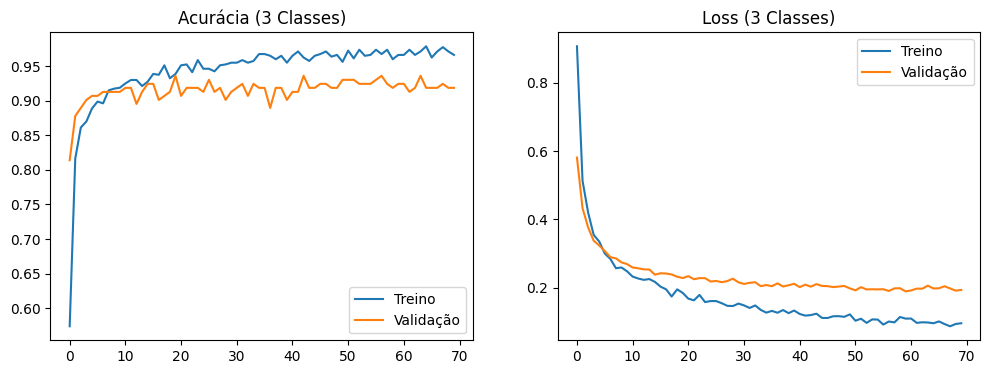

6/6 ━━━━━━━━━━━━━━━━━━━━ 58s 9s/step

--- RELATÓRIO DE CLASSIFICAÇÃO (3 CLASSES) ---
                  precision    recall  f1-score   support

       Non-Tumor     0.9524    0.9877    0.9697        81
Non-Viable-Tumor     0.9286    1.0000    0.9630        39
          Viable     1.0000    0.8846    0.9388        52

        accuracy                         0.9593       172
       macro avg     0.9603    0.9574    0.9571       172
    weighted avg     0.9614    0.9593    0.9588       172



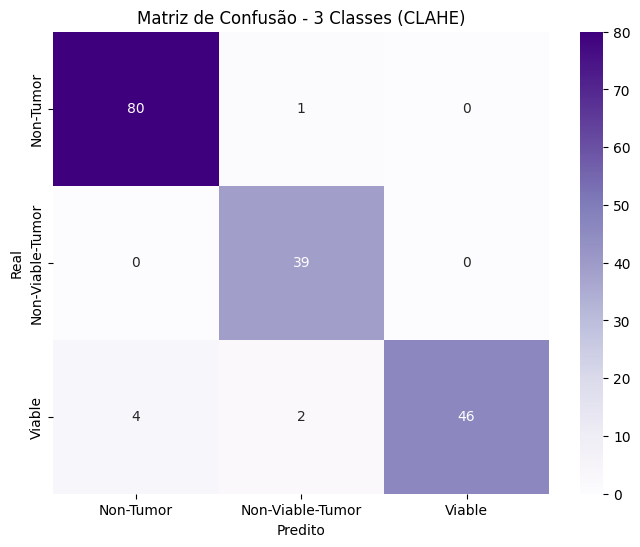

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Gráficos de Evolução
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia (3 Classes)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss (3 Classes)')
plt.legend()
plt.show()

# 2. Predição no conjunto de Teste
test_gen.reset()
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# 3. Relatório de Classificação Detalhado
print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (3 CLASSES) ---")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# 4. Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - 3 Classes (CLAHE)')
plt.show()